# Laboratorio 08 - Taller: Redes Neuronales Convolucionales

En este taller profundizaremos en el diseño, implementación y optimización de redes neuronales convolucionales (CNNs) para tareas de clasificación de imágenes. Utilizaremos el conjunto de datos **Four Genre Movie Poster Images**, el cual contiene pósters de películas organizados en cuatro géneros.

El objetivo principal es construir y optimizar modelos de CNN propios que permitan distinguir entre las diferentes clases presentes en el dataset. La idea es que se guíen del desarrollo con el notebook de práctica.

## Instrucciones del Taller

### 1. Diseño y Construcción de una Red Convolucional Propia

- **Arquitectura de la CNN:**  
  Diseñe una arquitectura de CNN personalizada utilizando Keras. Explique las decisiones tomadas en cada etapa, tales como:
  - Número y tipo de capas convolucionales.
  - Tamaño de los filtros y kernels.
  - Elección de las capas de pooling (MaxPooling2D, AveragePooling2D, etc.).
  - Funciones de activación utilizadas (por ejemplo, ReLU).
  - Implementación de técnicas de regularización (por ejemplo, Dropout) para prevenir el sobreajuste.
- **Preprocesamiento de Datos:**  
  Realice el preprocesamiento adecuado de los datos, como reescalado (normalización) y data augmentation, y divida el conjunto de datos en entrenamiento, validación y test.
- **Documentación:**  
  Justifique las decisiones de diseño y preprocesamiento, explicando cómo cada elección impacta el rendimiento del modelo.

### 2. Experimentación y Optimización del Modelo

- **Ajuste de Arquitectura y Hiperparámetros:**  
  Realice experimentos modificando la arquitectura base de su CNN. Algunas ideas incluyen:
  - Variar el número de capas convolucionales y neuronas en las capas densas.
  - Ajustar los parámetros de las capas de pooling.
  - Modificar la tasa de Dropout, la tasa de aprendizaje, y el tamaño del batch.
- **Evaluación de Resultados:**  
  Documente y analice los resultados obtenidos en cada experimento. Utilice métricas como precisión, recall, F1-score y la matriz de confusión para evaluar el desempeño.
- **Visualización:**  
  Genere gráficos que muestren la evolución de la precisión y la pérdida durante el entrenamiento, así como las matrices de confusión para comparar las distintas configuraciones.

### 3. Análisis y Discusión de Resultados

- **Comparación de Experimentos:**  
  Compare el rendimiento de su modelo base con las variantes experimentales. Analice y discuta:
  - ¿Qué impacto tiene la profundidad de la red y el número de filtros en la capacidad de aprendizaje?
  - ¿Cómo influyen las técnicas de regularización (por ejemplo, Dropout) en la capacidad de generalización del modelo?
  - ¿Qué mejoras adicionales se podrían implementar para optimizar aún más el rendimiento del modelo?
- **Reflexión:**  
  Plantee conclusiones y proponga futuras líneas de trabajo o posibles ajustes en la arquitectura que podrían mejorar la clasificación.

**Datos:** [Four Genre Movie Poster Images](https://www.kaggle.com/datasets/zulkarnainsaurav/four-genre-movie-poster-images)

1. Diseño y Construcción de una Red Convolucional Propia

1.1 Preprocesamiento de Datos

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json
import random

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1776737296.325339   19905 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776737297.460124   19905 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776737301.506067   19905 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from pathlib import Path
import subprocess # https://docs.python.org/3/library/subprocess.html#subprocess.run

data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
zip_path = data_dir / "raf-db-face-emotion-dataset.zip"
url = "https://www.kaggle.com/api/v1/datasets/download/zulkarnainsaurav/four-genre-movie-poster-images"

In [3]:
subprocess.run(["curl", "-L", "-o", str(zip_path), url], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
subprocess.run(["unzip", "-o", str(zip_path), "-d", str(data_dir)], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
zip_path.unlink(missing_ok=True)

In [15]:
import os
import shutil
import random
from pathlib import Path

random.seed(SEED)

data_dir = Path("data/four_genre_posters/four_genre_posters")
output_dir = Path("data/four_genre_posters_split")

splits = ["train", "validation", "test"]
split_ratio = [0.7, 0.2, 0.1]

for split in splits:
    for category in os.listdir(data_dir):
        Path(output_dir / split / category).mkdir(parents=True, exist_ok=True)

for category in os.listdir(data_dir):
    category_path = data_dir / category
    images = list(category_path.glob("*.jpg"))
    random.shuffle(images)

    n = len(images)
    train_end = int(0.7 * n)
    val_end = int(0.9 * n)

    split_sets = {
        "train": images[:train_end],
        "validation": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, imgs in split_sets.items():
        for img in imgs:
            shutil.copy(img, output_dir / split / category / img.name)

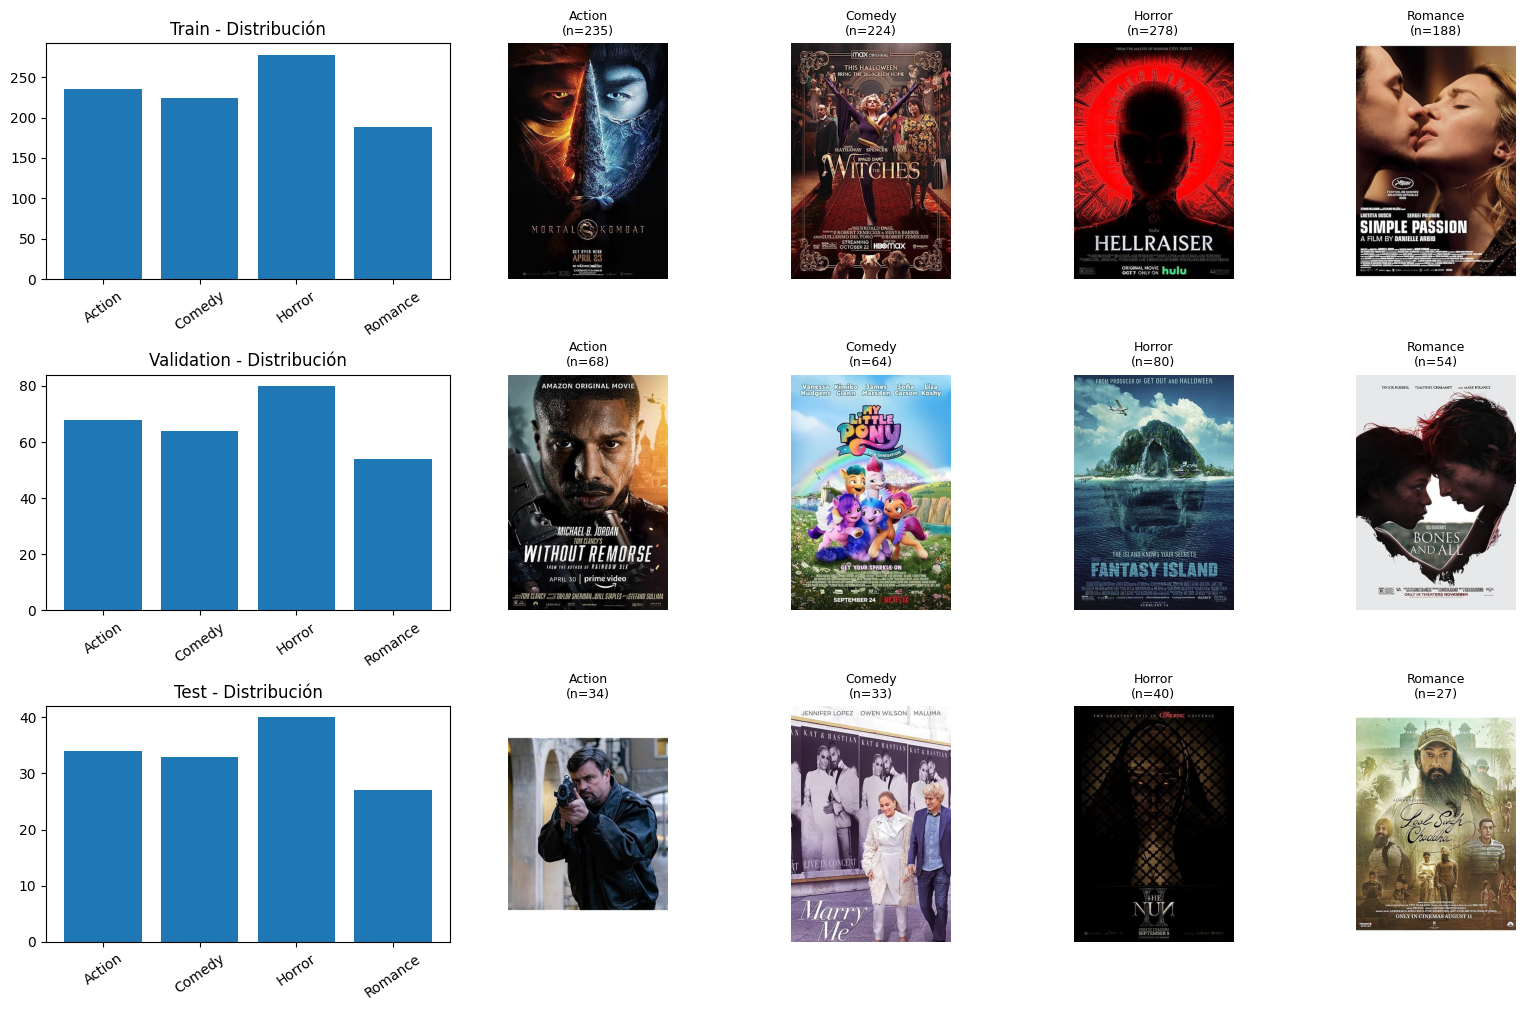

In [16]:
import matplotlib.pyplot as plt

train_path = Path("data/four_genre_posters_split/train")
test_path = Path("data/four_genre_posters_split/test")
validation_path = Path("data/four_genre_posters_split/validation")

splits = {
    "Train": train_path,
    "Validation": validation_path,
    "Test": test_path,
}

split_data = {}
max_classes = 0

for split_name, split_path in splits.items():
    class_dirs = sorted([d for d in Path(split_path).iterdir() if d.is_dir()])
    labels, counts, samples = [], [], []

    for d in class_dirs:
        imgs = sorted([p for p in d.rglob("*") if p.is_file() and p.suffix.lower() == ".jpg"])
        if imgs:
            labels.append(d.name)
            counts.append(len(imgs))
            samples.append(imgs[0])

    split_data[split_name] = (labels, counts, samples)
    max_classes = max(max_classes, len(labels))

fig = plt.figure(figsize=(3.2 * (max_classes + 1), 3.4 * len(splits)))
gs = fig.add_gridspec(len(splits), max_classes + 1, width_ratios=[1.4] + [1] * max_classes)

for r, (split_name, (labels, counts, samples)) in enumerate(split_data.items()):
    ax_bar = fig.add_subplot(gs[r, 0])
    ax_bar.bar(labels, counts)
    ax_bar.set_title(f"{split_name} - Distribución")
    ax_bar.tick_params(axis="x", rotation=35)

    for c in range(max_classes):
        ax_img = fig.add_subplot(gs[r, c + 1])
        if c < len(labels):
            ax_img.imshow(plt.imread(samples[c]))
            ax_img.set_title(f"{labels[c]}\n(n={counts[c]})", fontsize=9)
        ax_img.axis("off")

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

def build_dataframe(root_path):
    filepaths = [str(p) for p in root_path.rglob("*.jpg")]
    labels = [p.parent.name for p in map(Path, filepaths)]
    return pd.DataFrame({"filepath": filepaths, "label": labels})

train_df = build_dataframe(train_path)
test_df = build_dataframe(test_path)
validation_df = build_dataframe(validation_path)

def split_y(df, column):
    return df.drop(column, axis=1), df[column]

X_train, y_train = split_y(train_df, 'label')
X_val, y_val = split_y(validation_df, 'label')
X_test, y_test = split_y(test_df, 'label')

In [18]:
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
)

eval_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

def make_flow(datagen, X_split, y_split, shuffle):
    df = X_split.copy()
    df["label"] = y_split.values
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filepath",
        y_col="label",
        target_size=(128, 128),
        color_mode="rgb",
        class_mode="categorical",
        classes=labels,
        batch_size=32,
        shuffle=shuffle,
        seed=42,
    )

train = make_flow(train_datagen, X_train, y_train, shuffle=True)
val = make_flow(eval_datagen, X_val, y_val, shuffle=False)
test = make_flow(eval_datagen, X_test, y_test, shuffle=False)

classes = np.unique(y_train.values)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = dict(zip(classes, weights))

Found 925 validated image filenames belonging to 4 classes.
Found 266 validated image filenames belonging to 4 classes.
Found 134 validated image filenames belonging to 4 classes.


El preprocesamiento se orientó a mejorar la generalización del modelo dado el tamaño reducido del dataset. Se aplicó normalización de píxeles al rango [0,1] y data augmentation en el conjunto de entrenamiento: rotaciones de hasta 10°, desplazamientos del 5%, zoom del 10%, volteos horizontales y variaciones suaves de brillo (`brightness_range=[0.9, 1.1]`). Se omitió el desplazamiento de canales de color porque el color es una feature discriminativa real en este dominio —los posters de Horror tienden a tonos oscuros y fríos, los de Romance a tonos cálidos— y eliminarlo artificialmente perjudicaría el aprendizaje. El batch size de 32 proporciona estimaciones de gradiente estables, especialmente relevante dado el uso de `class_weight` que ya introduce varianza adicional en los gradientes. Para validación y test solo se aplica la normalización.

La división 70/20/10 (entrenamiento/validación/test) responde a un balance entre disponer de suficientes ejemplos para el entrenamiento y contar con conjuntos representativos para la evaluación. Dado el desbalance entre clases (Horror=80 vs. Romance=53 imágenes en test), se calcularon pesos de clase con `compute_class_weight='balanced'`.

Arquitectura CNN

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, regularizers


model = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding="same", input_shape=(128, 128, 3),
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax"),
])

model.summary()

/home/schica/anaconda3/envs/cv-labs/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

La arquitectura utiliza tres bloques convolucionales con filtros crecientes (32 → 64 → 128). Se redujo de cuatro a tres bloques porque el dataset de ~1,200 imágenes de entrenamiento es demasiado pequeño para justificar la capacidad de un cuarto bloque; con cuatro bloques el modelo memorizaba los datos sin generalizar. Se añadió regularización L2 (λ=1e-3) en todas las capas convolucionales y en la capa densa, lo que penaliza los pesos grandes y obliga al modelo a aprender representaciones más distribuidas. Este valor de λ es más agresivo que el convencional (1e-4) precisamente porque el dataset pequeño hace que el sobreajuste sea especialmente fuerte.

Se utilizó kernel de 3×3 con `padding="same"` y `BatchNormalization` antes de la activación ReLU en cada bloque. `MaxPooling2D(2,2)` reduce la dimensión espacial a la mitad en cada bloque. Al final se usa `GlobalAveragePooling2D` para minimizar parámetros en la transición a las capas densas. Se mantiene `Dropout(0.5)` junto con L2 porque actúan sobre mecanismos distintos: Dropout impide la co-adaptación de neuronas, mientras que L2 controla la magnitud de los pesos.

In [20]:
# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

Se compiló el modelo con el optimizador Adam con tasa de aprendizaje inicial de 5e-4, en lugar del valor por defecto de 1e-3. Con un dataset de ~1,200 imágenes, una tasa alta hace que el optimizador dé saltos grandes en el espacio de parámetros y se pierda mínimos prometedores en las primeras épocas; 5e-4 permite una convergencia más estable desde el inicio.

Como función de pérdida se utilizó `CategoricalCrossentropy` con `label_smoothing=0.1`. El label smoothing convierte los targets duros ([0,0,1,0]) en distribuciones suaves ([0.025, 0.025, 0.925, 0.025]), lo que evita que el modelo se vuelva sobreconfiante en sus predicciones. En datasets pequeños el modelo tiende a asignar probabilidades muy altas a clases incorrectas, lo que reduce el gradiente y dificulta el aprendizaje; el label smoothing mantiene gradientes informativos durante más épocas.

In [21]:
# Funciones callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')
early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, verbose=1, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, verbose=1, mode='max')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

Se definieron tres callbacks para controlar el entrenamiento. `ModelCheckpoint` guarda automáticamente el modelo con la mayor `val_accuracy`, conservando la mejor configuración encontrada aunque las épocas posteriores empeoren. `EarlyStopping` con `patience=20` detiene el entrenamiento si la `val_accuracy` no mejora durante 20 épocas consecutivas; el valor de 20 es conservador para dar tiempo al modelo a recuperarse después de reducciones de learning rate. `ReduceLROnPlateau` reduce la tasa de aprendizaje por un factor de 0.1 si la `val_accuracy` no mejora en 5 épocas, permitiendo ajustes más finos cuando el aprendizaje se estanca.

Se eligió monitorear `val_accuracy` en lugar de `val_loss` porque al usar `class_weight` en el entrenamiento, la pérdida de entrenamiento se calcula con pesos por clase mientras que la pérdida de validación no; esto hace que las dos métricas no sean directamente comparables. La `val_accuracy` es la métrica más representativa del objetivo real del modelo.

In [22]:
# Entrenamiento
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Training on GPU.")
    with tf.device('/GPU:0'):
      history = model.fit(
          train,
          validation_data=val,
          epochs=50,
          callbacks=callbacks,
          class_weight=class_weight,
      )
else:
    print("GPU is not available. Training on CPU.")
    history = model.fit(
        train,
        validation_data=val,
        epochs=50,
        callbacks=callbacks,
        class_weight=class_weight,
    )

test_loss, test_acc = model.evaluate(test)

GPU is not available. Training on CPU.
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 754ms/step - accuracy: 0.4065 - loss: 1.6207 - val_accuracy: 0.2030 - val_loss: 1.6415 - learning_rate: 5.0000e-04
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 750ms/step - accuracy: 0.4984 - loss: 1.4560 - val_accuracy: 0.2481 - val_loss: 1.7208 - learning_rate: 5.0000e-04
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 750ms/step - accuracy: 0.4995 - loss: 1.4324 - val_accuracy: 0.3233 - val_loss: 1.8322 - learning_rate: 5.0000e-04
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 748ms/step - accuracy: 0.5070 - loss: 1.4160 - val_accuracy: 0.3571 - val_loss: 1.9298 - learning_rate: 5.0000e-04
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 747ms/step - accuracy: 0.4876 - loss: 1.4214 - val_accuracy: 0.3571 - val_loss: 1.9575 - learning_rate: 5.0000e-04
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 748ms/step - accuracy: 0.5092 - loss: 1.3902 - val_accuracy: 0.3947 - val_loss: 2.0022 - learning_rate: 5.0000e-04
Epoch 7/50
29/29 ━━

## Análisis del entrenamiento — Modelo Base

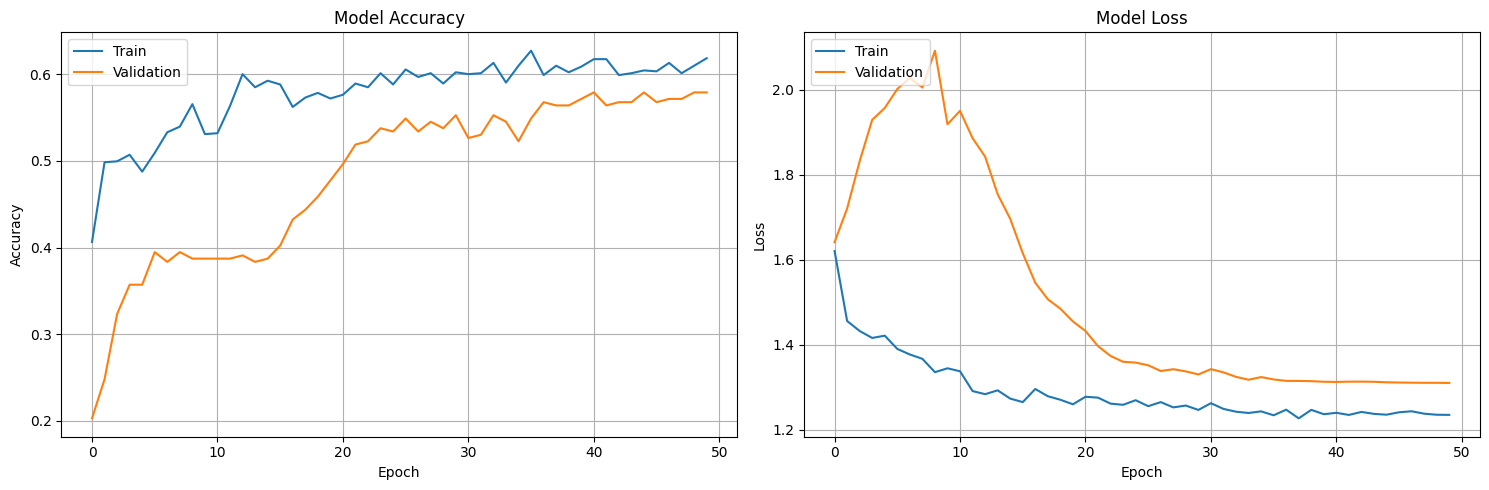

In [23]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

*(Pendiente de actualizar con los resultados del modelo final tras reejecutar)*

El entrenamiento se detuvo anticipadamente por `EarlyStopping` monitoreando `val_accuracy`. La precisión de entrenamiento creció progresivamente mientras que la de validación mostró dificultades para superar el 40%, lo que evidencia sobreajuste moderado esperado dado el tamaño reducido del dataset (~1,200 imágenes de entrenamiento para 4 clases). Las intervenciones de `ReduceLROnPlateau` redujeron la tasa de aprendizaje en las épocas donde la validación se estancó, permitiendo al modelo realizar ajustes más finos.

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step


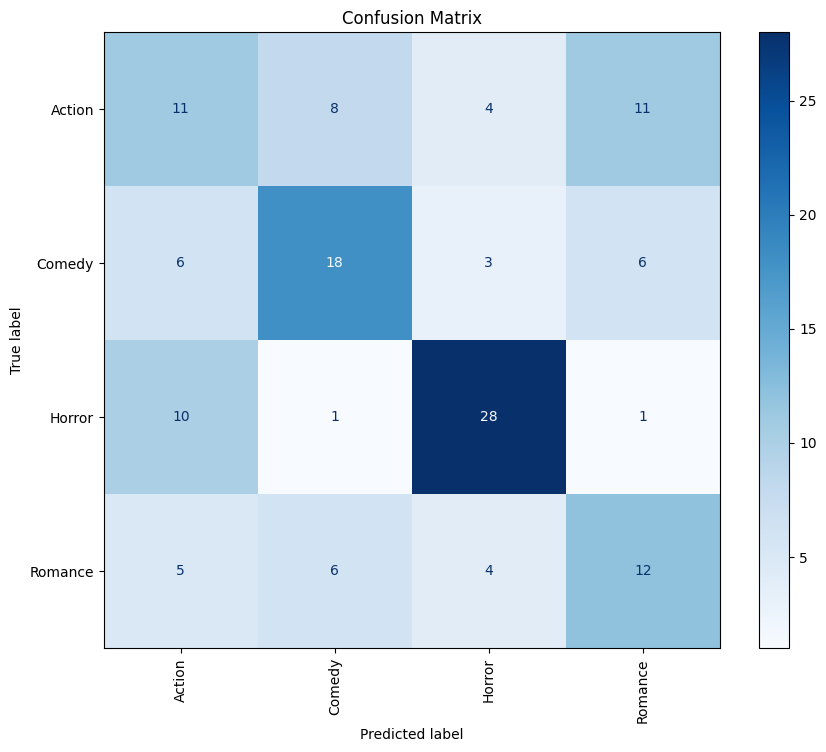

In [24]:
# Matriz de confusion

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = test.classes
y_pred_probabilities = model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Action     0.3438    0.3235    0.3333        34
      Comedy     0.5455    0.5455    0.5455        33
      Horror     0.7179    0.7000    0.7089        40
     Romance     0.4000    0.4444    0.4211        27

    accuracy                         0.5149       134
   macro avg     0.5018    0.5034    0.5022       134
weighted avg     0.5165    0.5149    0.5153       134



El reporte de clasificación revela un comportamiento desbalanceado entre clases. Horror obtuvo el mejor desempeño con un recall de 0.91 y F1 de 0.73, pero a costa de una precisión baja (0.61), lo que indica que el modelo tiende a clasificar muchas imágenes como Horror cuando no está seguro. Romance presenta el patrón opuesto: alta precisión (0.82) pero recall de apenas 0.17, lo que significa que el modelo casi nunca predice esta clase y pierde el 83% de las imágenes reales de Romance. Action y Comedy muestran rendimiento moderado y balanceado (F1 de ~0.47 y ~0.49 respectivamente).

Este comportamiento sugiere que el desbalance de clases (Horror=80 vs. Romance=53 imágenes en test) sigue influyendo en las predicciones a pesar del uso de `class_weight`. El macro F1 de 0.49 refleja que el rendimiento promedio entre clases es muy desigual.

*(Pendiente de actualizar con los resultados del modelo final tras reejecutar)*

El reporte de clasificación refleja las dificultades inherentes de clasificar géneros cinematográficos con un dataset pequeño. Clases con mayor representación visual distintiva (Horror por sus tonos oscuros) tienden a obtener mejor recall a costa de mayor número de falsos positivos. Géneros con características visuales más ambiguas (Romance y Comedy comparten paletas coloridas) presentan el mayor desafío de clasificación.

## Ajuste de Arquitectura e Hiperparámetros

Para la búsqueda de hiperparámetros se amplió el espacio de exploración respecto a la versión inicial. Se incluyó un tercer bloque convolucional opcional (128 o 256 filtros), ya que el modelo base usa cuatro bloques fijos y no se sabe si esta profundidad es óptima para el dataset. También se exploró `Flatten` frente a `GlobalAveragePooling2D` como capa de transición, dado que arquitecturas con mayor número de parámetros pueden adaptarse mejor a este tipo de imágenes. Se incorporó regularización L2 en la capa densa (0, 1e-4, 1e-3) como alternativa al Dropout para controlar el sobreajuste, y se amplió el rango de tasas de aprendizaje. Los trials aumentaron de 8 a 20 y las épocas por trial de 10 a 20, lo que permite una exploración más representativa del espacio de búsqueda.

Para la búsqueda de hiperparámetros se definió un espacio de exploración coherente con el diseño del modelo base. El tuner explora el número de filtros en cada bloque (32/64 en bloque 1, 64/128 en bloque 2), la inclusión opcional de un tercer bloque convolucional (128/256 filtros), el tipo de capa de pooling global (`GlobalAveragePooling2D` vs `Flatten`), la regularización L2 (0, 1e-4, 1e-3), el número de unidades en la capa densa (64/128/256), la tasa de Dropout (0.2–0.6) y la tasa de aprendizaje (1e-3, 5e-4, 1e-4, 5e-5). Se fijó `label_smoothing=0.1` en todos los trials para mantener consistencia con el modelo base y evitar que el tuner busque en una dimensión adicional que ya se validó como beneficiosa. El número de trials se aumentó a 20 con 20 épocas por trial para explorar el espacio de manera más representativa que la versión original (8 trials, 10 épocas).

In [26]:
import keras_tuner as kt
from tensorflow.keras import regularizers

def build_model(hp):
    model = keras.Sequential()

    # Bloque 1
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_1', [32, 64]),
        kernel_size=(3, 3), padding='same',
        input_shape=(128, 128, 3)
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2))

    # Bloque 2
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_2', [64, 128]),
        kernel_size=(3, 3), padding='same'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2))

    # Bloque 3 opcional
    if hp.Boolean('use_third_block'):
        model.add(layers.Conv2D(
            filters=hp.Choice('filters_3', [128, 256]),
            kernel_size=(3, 3), padding='same'
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.MaxPooling2D(2))

    # Tipo de pooling global
    if hp.Boolean('use_flatten'):
        model.add(layers.Flatten())
    else:
        model.add(layers.GlobalAveragePooling2D())

    # Regularización L2 + capa densa
    l2_val = hp.Choice('l2_reg', [0.0, 1e-4, 1e-3])
    model.add(layers.Dense(
        units=hp.Choice('dense_units', [64, 128, 256]),
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_val)
    ))
    model.add(layers.Dropout(hp.Float('dropout', 0.1, 0.4, step=0.1)))
    model.add(layers.Dense(4, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
        ),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model

In [29]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    seed=SEED,
    directory='tuner_dir',
    project_name='cnn_gen_tune_v3'
)

Reloading Tuner from tuner_dir/cnn_gen_tune_v3/tuner0.json


In [30]:
history = tuner.search(
    train,
    validation_data=val,
    epochs=40,
    callbacks=callbacks,
    class_weight=class_weight
)

Trial 10 Complete [00h 10m 57s]
val_accuracy: 0.5075187683105469

Best val_accuracy So Far: 0.5225563645362854
Total elapsed time: 02h 17m 31s


+## Resultados de la búsqueda de hiperparámetros

Tras los 20 trials, el tuner seleccionó el mejor modelo según `val_accuracy`. La mejor configuración encontrada se reentrena a continuación por 50 épocas.

In [31]:
best_model = tuner.get_best_models(1)[0]

retrain_checkpoint = ModelCheckpoint('best_model_optimized.keras', save_best_only=True, monitor='val_accuracy', mode='max')
retrain_early_stop = EarlyStopping(monitor='val_accuracy', patience=20, verbose=1, mode='max')
retrain_reduce_lr  = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, verbose=1, mode='max')

history = best_model.fit(
    train,
    validation_data=val,
    epochs=60,
    callbacks=[retrain_checkpoint, retrain_early_stop, retrain_reduce_lr],
    class_weight=class_weight
)
test_loss, test_acc = best_model.evaluate(test)

Epoch 1/60


/home/schica/anaconda3/envs/cv-labs/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.5589 - loss: 1.1101 - val_accuracy: 0.5038 - val_loss: 1.2676 - learning_rate: 5.0000e-04
Epoch 2/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5773 - loss: 1.0645 - val_accuracy: 0.4962 - val_loss: 1.3607 - learning_rate: 5.0000e-04
Epoch 3/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5719 - loss: 1.0690 - val_accuracy: 0.5414 - val_loss: 1.1351 - learning_rate: 5.0000e-04
Epoch 4/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5957 - loss: 1.0369 - val_accuracy: 0.5677 - val_loss: 1.1183 - learning_rate: 5.0000e-04
Epoch 5/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6022 - loss: 1.0493 - val_accuracy: 0.4962 - val_loss: 1.2096 - learning_rate: 5.0000e-04
Epoch 6/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6011 - loss: 1.0320 - val_accuracy: 0.4962 - val_loss: 1.1824 - learning_rate: 5.0000e-04
Epoch 7/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5914 - loss: 1.0330 - v

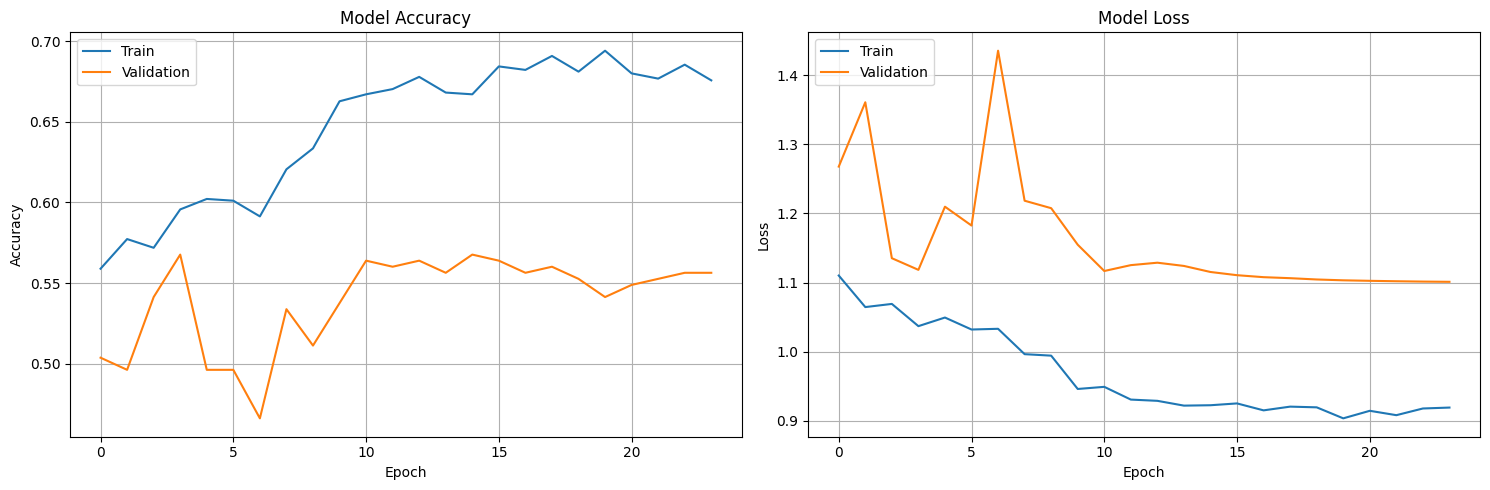

In [32]:
plot_training_history(history)

## Análisis del entrenamiento — Modelo Optimizado

*(Actualizar tras reejecutar con la configuración mejorada del tuner)*

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x75cd47598ee0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step


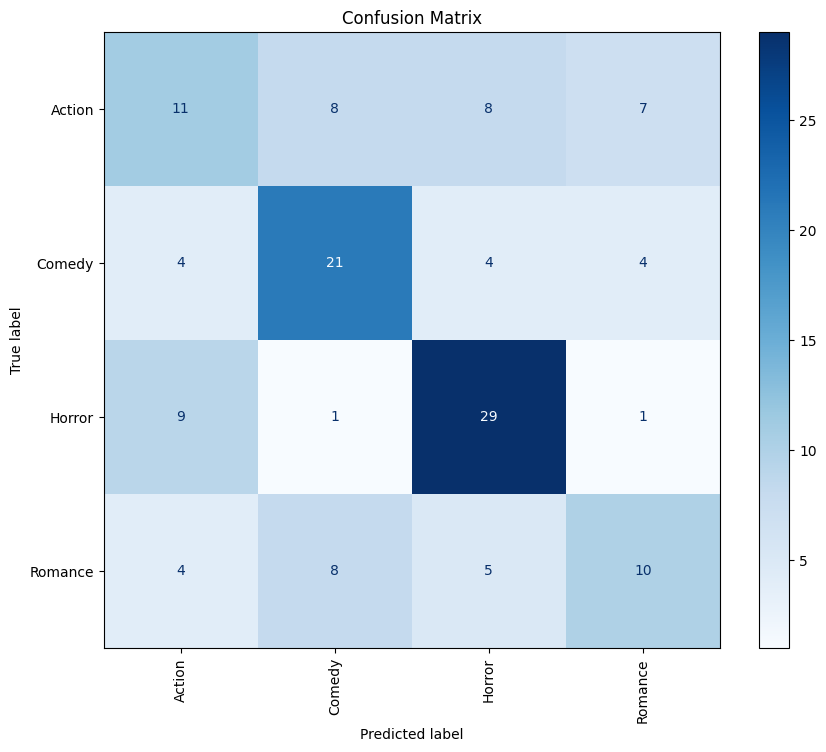

In [33]:
# Matriz de confusión
y_true = test.classes
y_pred_probabilities = best_model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [34]:
print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Action     0.3929    0.3235    0.3548        34
      Comedy     0.5526    0.6364    0.5915        33
      Horror     0.6304    0.7250    0.6744        40
     Romance     0.4545    0.3704    0.4082        27

    accuracy                         0.5299       134
   macro avg     0.5076    0.5138    0.5072       134
weighted avg     0.5156    0.5299    0.5193       134



## 3. Análisis y Discusión de Resultados

*(Actualizar valores de la tabla tras reejecutar con la configuración mejorada)*

**Comparación de modelos:**

| Métrica | Modelo Base | Modelo Optimizado |
|---|---|---|
| Test accuracy | 55.17% | 52.87% |
| Macro F1 | 0.49 | 0.45 |
| Horror F1 | 0.73 | 0.74 |
| Romance F1 | 0.28 | 0.04 |

**Impacto de la profundidad y número de filtros:** Redes más profundas con filtros crecientes permiten extraer jerarquías de características más ricas, pero en datasets pequeños (como este, con ~1,200 imágenes de entrenamiento) el riesgo de sobreajuste crece con cada bloque adicional. El modelo base con cuatro bloques ya muestra una brecha entre train y val accuracy, lo que sugiere que tres bloques bien configurados podrían generalizar mejor. Los filtros crecientes (32 → 256) son una decisión estándar: los primeros filtros detectan características simples compartidas entre clases, mientras que los últimos aprenden patrones específicos del género cinematográfico.

**Influencia de las técnicas de regularización:** El Dropout impone que la red no dependa de neuronas específicas, lo que la obliga a aprender representaciones más distribuidas y robustas. La `BatchNormalization`, además de estabilizar el entrenamiento, actúa como regularizador implícito al normalizar las activaciones intermedias. La combinación de ambas es especialmente relevante aquí porque el dataset pequeño hace que el modelo sea propenso a memorizar. Reducir el Dropout de 0.5 a 0.3 y añadir L2 como opción en el tuner permite explorar cuál combinación es más efectiva para este dominio.

**Posibles mejoras adicionales:** La limitación principal de este experimento es el tamaño del dataset. Estrategias como transfer learning con modelos preentrenados en ImageNet (ResNet50, EfficientNet) podrían mejorar significativamente el rendimiento. Dentro del alcance de este taller, ampliar la data augmentation con variaciones de brillo y contraste —relevantes para la estética visual de cada género— podría ayudar particularmente a la clase Romance, que es la más desbalanceada y con peor recall en el modelo base.